 ### Load & Rename Columns

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
# Load the uploaded file 
df = pd.read_csv('dataset.csv')

In [25]:

df.columns = [
    'id', 'duration_months', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment_years', 'installment_rate_pct',
    'personal_status', 'other_debtors', 'present_residence_years',
    'property', 'age_years', 'other_installment_plans', 'housing',
    'existing_credits_count', 'job', 'num_dependents', 'telephone',
    'foreign_worker', 'credit_risk'   # this is the target, despite the original header name
]

df.head()

,id,duration_months,credit_history,purpose,credit_amount,savings_status,employment_years,installment_rate_pct,personal_status,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,credit_risk
0,1,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Confirm & Encode Target

In [30]:
print(df['credit_risk'].value_counts())

# Encode target: 0 = good, 1 = bad (default)
df['target'] = df['credit_risk'].str.strip().str.lower().map({'good': 0, 'bad': 1})

# Sanity check — should have zero nulls after mapping
print(df['target'].isnull().sum(), "unmapped rows")
print(df['target'].value_counts(normalize=True))

credit_risk
good    700
bad     300
Name: count, dtype: int64
0 unmapped rows
target
0    0.7
1    0.3
Name: proportion, dtype: float64


### Data Quality Check

In [33]:
# Missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

# Data types
print(df.dtypes)

# Drop id column — not predictive
df = df.drop(columns=['id', 'credit_risk'])

# Basic stats on numeric columns
numeric_cols = ['duration_months', 'credit_amount', 'installment_rate_pct',
                 'present_residence_years', 'age_years', 'existing_credits_count',
                 'num_dependents']
df[numeric_cols].describe()

Series([], dtype: int64)
id                          int64
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_status             object
employment_years           object
installment_rate_pct        int64
personal_status            object
other_debtors              object
present_residence_years     int64
property                   object
age_years                   int64
other_installment_plans    object
housing                    object
existing_credits_count      int64
job                        object
num_dependents              int64
telephone                  object
foreign_worker             object
credit_risk                object
target                      int64
dtype: object


,duration_months,credit_amount,installment_rate_pct,present_residence_years,age_years,existing_credits_count,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


### Univariate: Numeric Distributions

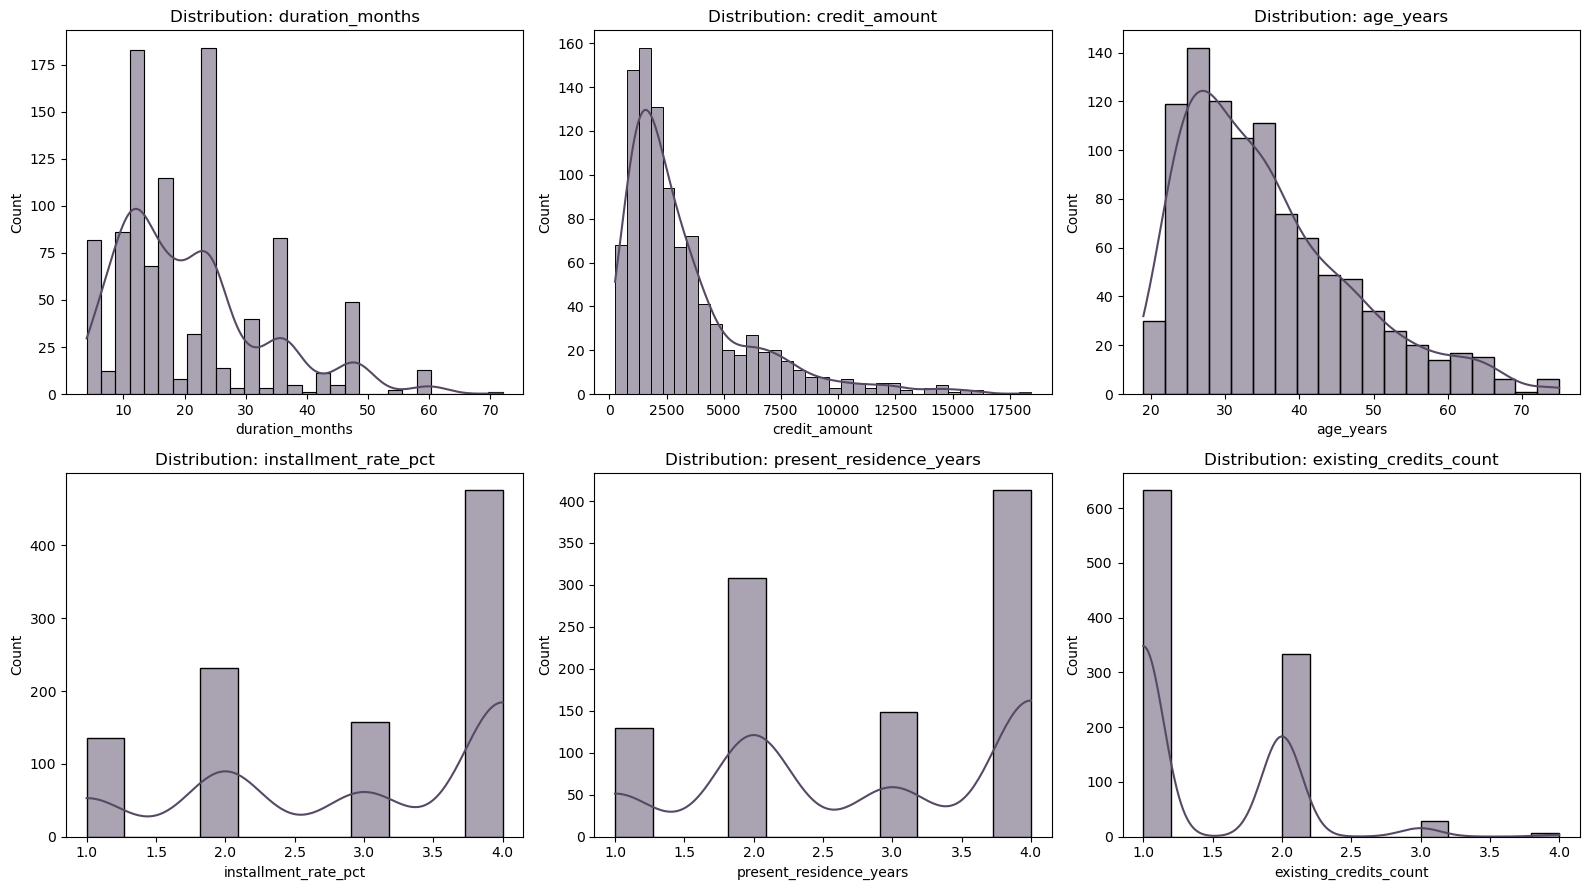

In [154]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(['duration_months', 'credit_amount', 'age_years',
                          'installment_rate_pct', 'present_residence_years',
                          'existing_credits_count']):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#574964')
    axes[i].set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

### Bivariate: Default Rate by Key Categorical Features

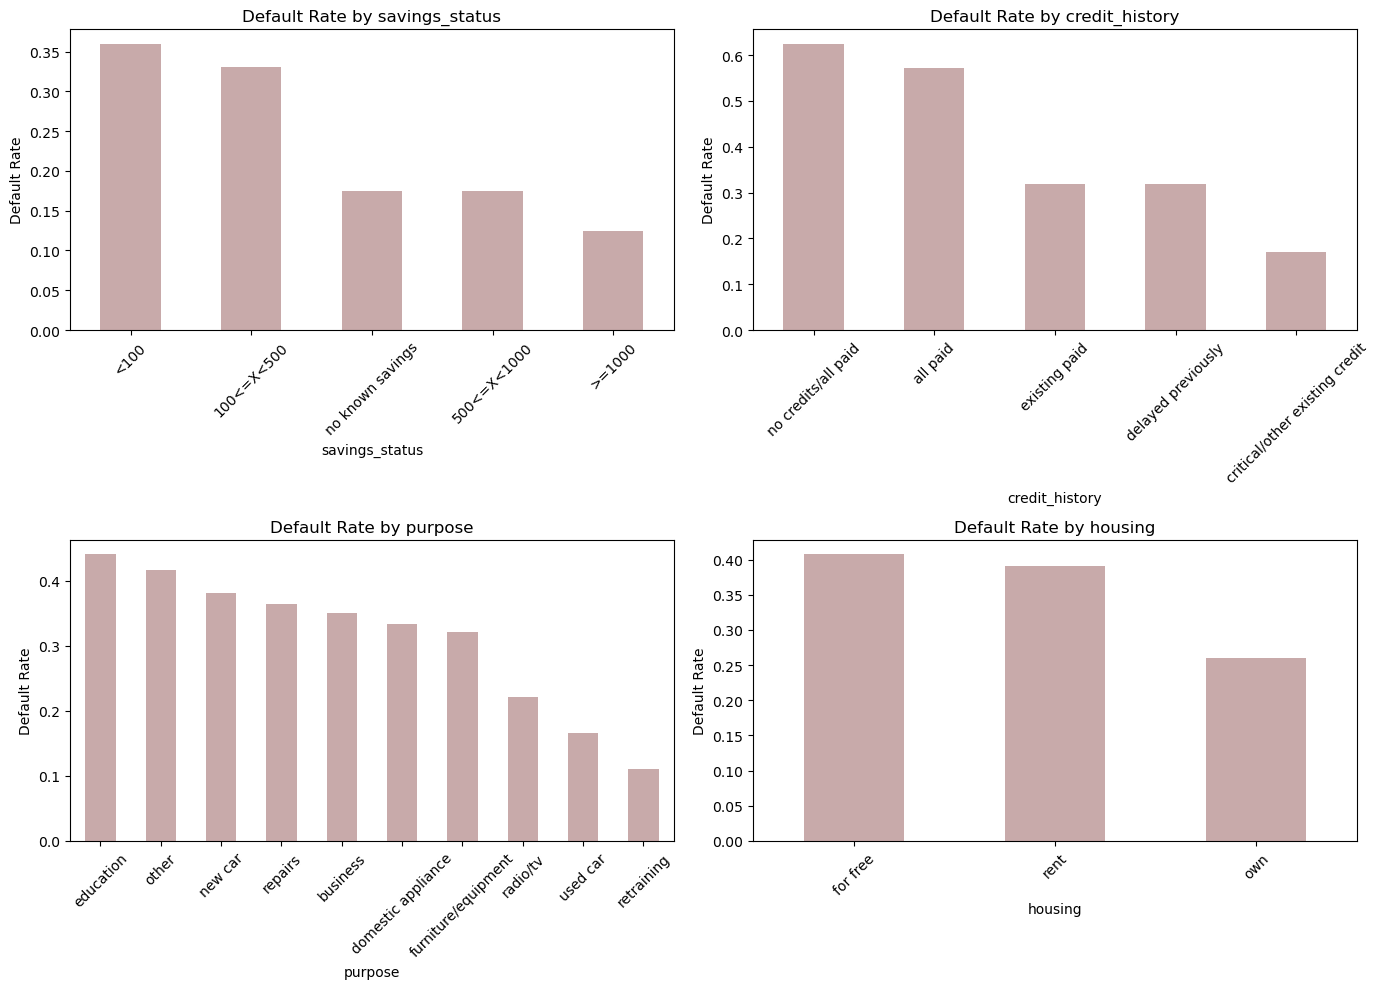

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['savings_status', 'credit_history',
                                      'purpose', 'housing']):
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#C8AAAA')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Correlation Matrix (Numeric Features)

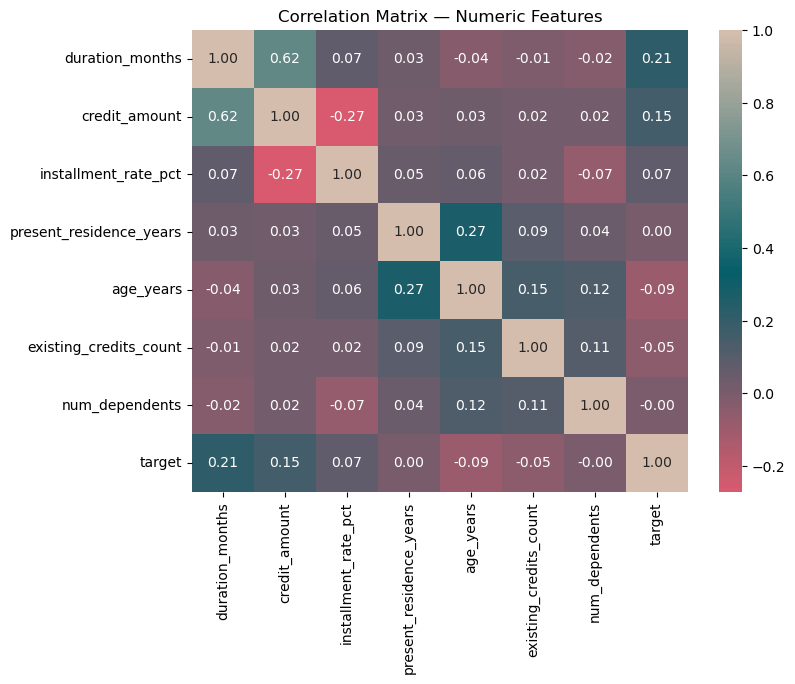

In [170]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'custom_palette', ['#FFF1DB', '#EF5A6F', '#055E68', '#D4BDAC']
)

corr = df[numeric_cols + ['target']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=custom_cmap, center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

### Chi-Square Tests (Categorical Features vs Default)

In [79]:
from scipy.stats import chi2_contingency

categorical_cols = ['credit_history', 'purpose', 'savings_status', 'employment_years',
                     'personal_status', 'other_debtors', 'property',
                     'other_installment_plans', 'housing', 'job',
                     'telephone', 'foreign_worker']

chi_results = []

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({'feature': col, 'chi2_stat': chi2, 'p_value': p,
                         'significant_at_0.05': p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values('p_value')
chi_df

,feature,chi2_stat,p_value,significant_at_0.05
0,credit_history,61.691397,1.279187e-12,True
2,savings_status,36.098928,2.761214e-07,True
6,property,23.719551,2.858442e-05,True
8,housing,18.199842,1.116747e-04,True
1,purpose,33.356447,1.157491e-04,True
3,employment_years,18.368274,1.045452e-03,True
7,other_installment_plans,12.839188,1.629318e-03,True
11,foreign_worker,5.821576,1.583075e-02,True
4,personal_status,9.605214,2.223801e-02,True
5,other_debtors,6.645367,3.605595e-02,True


###  T-Tests (Numeric Features: Good vs Bad Credit)

In [82]:
from scipy.stats import ttest_ind

ttest_results = []

for col in numeric_cols:
    good = df[df['target'] == 0][col]
    bad = df[df['target'] == 1][col]
    t_stat, p_val = ttest_ind(good, bad, equal_var=False)  # Welch's t-test, safer default
    ttest_results.append({'feature': col, 't_stat': t_stat, 'p_value': p_val,
                           'good_mean': good.mean(), 'bad_mean': bad.mean(),
                           'significant_at_0.05': p_val < 0.05})

ttest_df = pd.DataFrame(ttest_results).sort_values('p_value')
ttest_df

,feature,t_stat,p_value,good_mean,bad_mean,significant_at_0.05
0,duration_months,-6.469554,2.404081e-10,19.207143,24.860000,True
1,credit_amount,-4.264219,2.477713e-05,2985.457143,3938.126667,True
4,age_years,2.907152,3.788491e-03,36.224286,33.963333,True
2,installment_rate_pct,-2.326450,2.033538e-02,2.920000,3.096667,True
5,existing_credits_count,1.471787,1.416126e-01,1.424286,1.366667,False
6,num_dependents,0.095447,9.239934e-01,1.155714,1.153333,False
3,present_residence_years,-0.094207,9.249780e-01,2.842857,2.850000,False


### Effect Size (Cohen's d) for Significant Numeric Features

In [85]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

effect_sizes = []
for col in numeric_cols:
    good = df[df['target'] == 0][col]
    bad = df[df['target'] == 1][col]
    d = cohens_d(bad, good)
    effect_sizes.append({'feature': col, 'cohens_d': d})

pd.DataFrame(effect_sizes).sort_values('cohens_d', key=abs, ascending=False)

,feature,cohens_d
0,duration_months,0.479751
1,credit_amount,0.341442
4,age_years,-0.199487
2,installment_rate_pct,0.158256
5,existing_credits_count,-0.099801
6,num_dependents,-0.006572
3,present_residence_years,0.006468


###  WOE/IV for Categorical Features

In [88]:
def calculate_woe_iv_categorical(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    # Add small constant to avoid division by zero
    grouped['dist_good'] = (grouped['good'] + 0.5) / (total_good + 0.5 * len(grouped))
    grouped['dist_bad'] = (grouped['bad'] + 0.5) / (total_bad + 0.5 * len(grouped))

    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    grouped['iv_contribution'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']

    iv = grouped['iv_contribution'].sum()
    return grouped, iv

significant_categoricals = ['credit_history', 'savings_status', 'property', 'housing',
                             'purpose', 'employment_years', 'other_installment_plans',
                             'foreign_worker', 'personal_status', 'other_debtors']

iv_summary = []
woe_tables = {}

for feat in significant_categoricals:
    woe_table, iv = calculate_woe_iv_categorical(df, feat, 'target')
    woe_tables[feat] = woe_table
    iv_summary.append({'feature': feat, 'iv': iv})

iv_df = pd.DataFrame(iv_summary).sort_values('iv', ascending=False)
iv_df

,feature,iv
0,credit_history,0.290832
1,savings_status,0.187938
4,purpose,0.163613
2,property,0.111799
5,employment_years,0.085656
3,housing,0.083800
6,other_installment_plans,0.058441
8,personal_status,0.044830
7,foreign_worker,0.039274
9,other_debtors,0.031128


### IV Strength Interpretation


In [91]:
def iv_strength(iv):
    if iv < 0.02: return 'Not useful'
    elif iv < 0.1: return 'Weak'
    elif iv < 0.3: return 'Medium'
    elif iv < 0.5: return 'Strong'
    else: return 'Suspicious (check for leakage)'

iv_df['strength'] = iv_df['iv'].apply(iv_strength)
iv_df

,feature,iv,strength
0,credit_history,0.290832,Medium
1,savings_status,0.187938,Medium
4,purpose,0.163613,Medium
2,property,0.111799,Medium
5,employment_years,0.085656,Weak
3,housing,0.083800,Weak
6,other_installment_plans,0.058441,Weak
8,personal_status,0.044830,Weak
7,foreign_worker,0.039274,Weak
9,other_debtors,0.031128,Weak


 ### Bin Numeric Features, Then WOE/IV

In [95]:
numeric_significant = ['duration_months', 'credit_amount', 'age_years', 'installment_rate_pct']

for col in numeric_significant:
    df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')

for feat in numeric_significant:
    bin_col = f'{feat}_bin'
    woe_table, iv = calculate_woe_iv_categorical(df, bin_col, 'target')
    woe_tables[bin_col] = woe_table
    iv_summary.append({'feature': bin_col, 'iv': iv})

iv_df = pd.DataFrame(iv_summary).sort_values('iv', ascending=False)
iv_df['strength'] = iv_df['iv'].apply(iv_strength)
iv_df

C:\Users\laptop\AppData\Local\Temp\ipykernel_9460\624192344.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\laptop\AppData\Local\Temp\ipykernel_9460\624192344.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\laptop\AppData\Local\Temp\ipykernel_9460\624192344.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

,feature,iv,strength
0,credit_history,0.290832,Medium
10,duration_months_bin,0.213164,Medium
1,savings_status,0.187938,Medium
4,purpose,0.163613,Medium
2,property,0.111799,Medium
11,credit_amount_bin,0.092127,Weak
5,employment_years,0.085656,Weak
3,housing,0.083800,Weak
12,age_years_bin,0.067332,Weak
6,other_installment_plans,0.058441,Weak


 ### Final Feature Set + WOE Transformation

In [98]:
final_features = ['credit_history', 'duration_months_bin', 'savings_status', 'purpose',
                   'property', 'credit_amount_bin', 'employment_years', 'housing',
                   'age_years_bin', 'other_installment_plans', 'personal_status',
                   'foreign_worker']

# Replace each feature's categories with their WOE value
df_woe = df.copy()

for feat in final_features:
    woe_map = woe_tables[feat]['woe'].to_dict()
    df_woe[f'{feat}_woe'] = df_woe[feat].map(woe_map)

woe_cols = [f'{feat}_woe' for feat in final_features]
df_woe[woe_cols].head()

,credit_history_woe,duration_months_bin_woe,savings_status_woe,purpose_woe,property_woe,credit_amount_bin_woe,employment_years_woe,housing_woe,age_years_bin_woe,other_installment_plans_woe,personal_status_woe,foreign_worker_woe
0,0.730579,0.467357,0.696781,0.413733,0.458777,-0.016394,0.235160,0.195267,0.234771,0.122643,0.167163,-0.033905
1,-0.085155,-0.762061,-0.267631,0.413733,0.458777,-0.541810,-0.030040,0.195267,-0.404139,0.122643,-0.233642,-0.033905
2,0.730579,0.467357,-0.267631,-0.601497,0.458777,0.146261,0.390107,0.195267,0.234771,0.122643,0.167163,-0.033905
3,-0.085155,-0.762061,-0.267631,-0.090672,-0.028699,-0.541810,0.390107,-0.473275,0.186334,0.122643,0.167163,-0.033905
4,-0.089825,-0.098238,-0.267631,-0.351949,-0.583995,-0.541810,-0.030040,-0.473275,0.234771,0.122643,0.167163,-0.033905


### VIF Check (Multicollinearity)

In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_woe[woe_cols].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = woe_cols
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(woe_cols))]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
4,property_woe,1.359865
1,duration_months_bin_woe,1.299324
5,credit_amount_bin_woe,1.264664
7,housing_woe,1.233098
8,age_years_bin_woe,1.129035
6,employment_years_woe,1.110593
10,personal_status_woe,1.096419
0,credit_history_woe,1.089037
9,other_installment_plans_woe,1.060398
11,foreign_worker_woe,1.040781


 ### Train/Test Split

In [102]:
from sklearn.model_selection import train_test_split

X = df_woe[woe_cols].dropna()
y = df_woe.loc[X.index, 'target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}, Test default rate: {y_test.mean():.3f}")

Train: (800, 12), Test: (200, 12)
Train default rate: 0.300, Test default rate: 0.300


###  Logistic Regression

In [112]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Using statsmodels for full statistical output (coefficients, p-values, std errors)
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.498793
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  800
Model:                          Logit   Df Residuals:                      787
Method:                           MLE   Df Model:                           12
Date:                Fri, 03 Jul 2026   Pseudo R-squ.:                  0.1835
Time:                        11:28:16   Log-Likelihood:                -399.03
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 5.899e-32
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.8571      0.089     -9.623      0.000   

###  sklearn Version (for prediction/scoring pipeline)

In [115]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(random_state=42, max_iter=1000)
sk_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': sk_model.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
5,credit_amount_bin_woe,-0.326517
7,housing_woe,-0.532416
8,age_years_bin_woe,-0.533127
4,property_woe,-0.657206
0,credit_history_woe,-0.712836
11,foreign_worker_woe,-0.715867
6,employment_years_woe,-0.745017
9,other_installment_plans_woe,-0.789603
1,duration_months_bin_woe,-0.868243
3,purpose_woe,-0.913167


### Refined Model (Significant Features Only)

In [118]:
significant_features = ['credit_history_woe', 'duration_months_bin_woe', 'savings_status_woe',
                         'purpose_woe', 'property_woe', 'employment_years_woe',
                         'other_installment_plans_woe', 'personal_status_woe']

X_train_sig = X_train[significant_features]
X_test_sig = X_test[significant_features]

X_train_sig_sm = sm.add_constant(X_train_sig)
logit_model_v2 = sm.Logit(y_train, X_train_sig_sm)
result_v2 = logit_model_v2.fit()

print(result_v2.summary())

Optimization terminated successfully.
         Current function value: 0.505671
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  800
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            8
Date:                Fri, 03 Jul 2026   Pseudo R-squ.:                  0.1722
Time:                        11:32:27   Log-Likelihood:                -404.54
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 2.916e-32
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.8519      0.088     -9.687      0.000   

 ### Refit sklearn Version (for scoring/prediction)

In [120]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(random_state=42, max_iter=1000)
sk_model.fit(X_train_sig, y_train)

coef_df = pd.DataFrame({
    'feature': X_train_sig.columns,
    'coefficient': sk_model.coef_[0]
}).sort_values('coefficient')

coef_df

,feature,coefficient
2,savings_status_woe,-1.065781
7,personal_status_woe,-1.050599
1,duration_months_bin_woe,-0.961426
4,property_woe,-0.852459
3,purpose_woe,-0.849744
5,employment_years_woe,-0.800979
0,credit_history_woe,-0.749598
6,other_installment_plans_woe,-0.718703


### Predictions & Core Evaluation Metrics

In [122]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

y_pred_proba = sk_model.predict_proba(X_test_sig)[:, 1]
y_pred = sk_model.predict(X_test_sig)

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))

ROC-AUC: 0.7377

Confusion Matrix:
[[127  13]
 [ 40  20]]

Classification Report:
              precision    recall  f1-score   support

        Good       0.76      0.91      0.83       140
         Bad       0.61      0.33      0.43        60

    accuracy                           0.73       200
   macro avg       0.68      0.62      0.63       200
weighted avg       0.71      0.73      0.71       200



### KS Statistic (Bank-Standard Metric)

In [124]:
from scipy.stats import ks_2samp

good_scores = y_pred_proba[y_test == 0]
bad_scores = y_pred_proba[y_test == 1]

ks_stat, ks_pvalue = ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"KS p-value: {ks_pvalue:.4e}")

KS Statistic: 0.4333
KS p-value: 1.3324e-07


### ROC Curve Plot

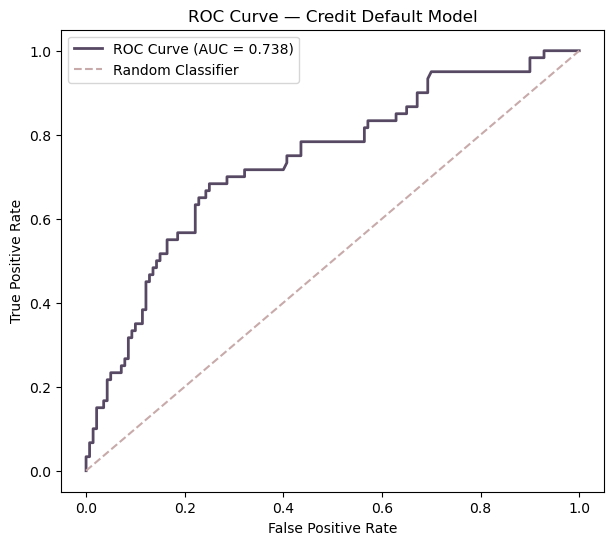

In [126]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#574964', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='#C8AAAA', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Default Model')
plt.legend()
plt.show()

###  PDO Scorecard Conversion

In [133]:
# PDO (Points to Double the Odds) scaling parameters — bank-standard defaults
base_score = 600      # score at base odds
base_odds = 50        # odds of good:bad at base_score (50:1)
pdo = 20               # points needed to double the odds

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

print(f"Factor: {factor:.4f}, Offset: {offset:.4f}")

Factor: 28.8539, Offset: 487.1229


 ### Convert Each Feature's WOE into Points

In [136]:
intercept = result_v2.params['const']
coefficients = result_v2.params.drop('const')

scorecard_tables = {}

for feat in significant_features:
    base_feat = feat.replace('_woe', '')
    woe_table = woe_tables[base_feat].copy()
    coef = coefficients[feat]

    # Points formula: -(woe * coef + intercept/n_features) * factor + offset/n_features
    n_features = len(significant_features)
    woe_table['points'] = -(woe_table['woe'] * coef + intercept / n_features) * factor + offset / n_features
    woe_table['points'] = woe_table['points'].round(0).astype(int)

    scorecard_tables[base_feat] = woe_table[['points']]
    print(f"\n--- {base_feat} ---")
    print(woe_table[['woe', 'points']])


--- credit_history ---
                                     woe  points
credit_history                                  
all paid                       -1.124415      39
critical/other existing credit  0.730579      80
delayed previously             -0.089825      62
existing paid                  -0.085155      62
no credits/all paid            -1.340403      34

--- duration_months_bin ---
                          woe  points
duration_months_bin                  
(3.999, 12.0]        0.467357      78
(12.0, 15.0]         0.640723      83
(15.0, 24.0]        -0.098238      61
(24.0, 30.0]        -0.162320      59
(30.0, 72.0]        -0.762061      42

--- savings_status ---
                       woe  points
savings_status                    
100<=X<500       -0.142197      59
500<=X<1000       0.675902      86
<100             -0.267631      55
>=1000            1.035138      98
no known savings  0.696781      87

--- purpose ---
                          woe  points
purpose       

### Score Every Applicant

In [140]:
def calculate_score(row):
    total = 0
    for feat in significant_features:
        base_feat = feat.replace('_woe', '')
        # get the applicant's bin/category value
        if base_feat.endswith('_bin'):
            category = df.loc[row.name, base_feat]
        else:
            category = df.loc[row.name, base_feat]
        total += scorecard_tables[base_feat].loc[category, 'points']
    return total

# Apply to full dataset
df['credit_score'] = df.apply(calculate_score, axis=1)
df[['credit_score', 'target']].describe()

,credit_score,target
count,1000.000000,1000.000000
mean,518.369000,0.300000
std,33.641055,0.458487
min,416.000000,0.000000
25%,496.000000,0.000000
50%,519.000000,0.000000
75%,542.000000,1.000000
max,608.000000,1.000000


### Validate: Score Distribution by Actual Risk

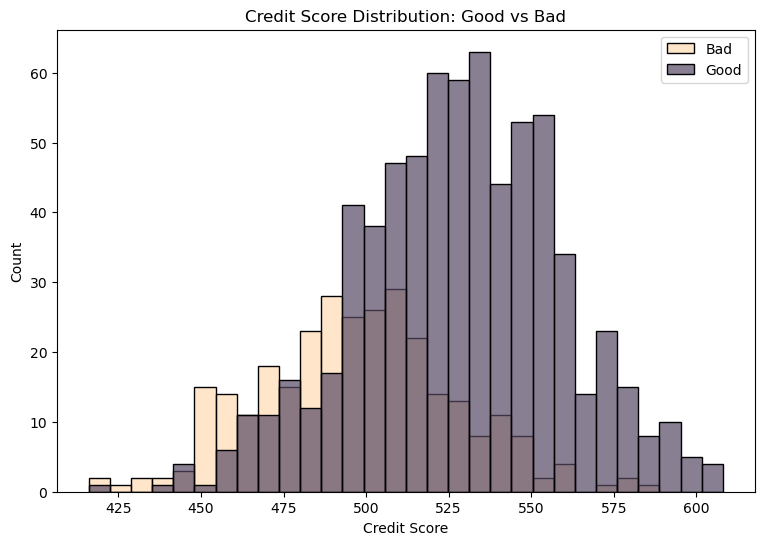

        count    mean        std    min    25%    50%     75%    max
target                                                              
0       700.0  527.72  30.767975  420.0  507.0  529.0  549.00  608.0
1       300.0  496.55  29.761496  416.0  476.0  496.5  514.25  584.0


In [144]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(data=df, x='credit_score', hue='target', bins=30,
             palette={0: '#574964', 1: '#FFDAB3'}, ax=ax, alpha=0.7)
ax.set_title('Credit Score Distribution: Good vs Bad')
ax.set_xlabel('Credit Score')
plt.legend(labels=['Bad', 'Good'])
plt.show()

# Sanity check — bad credit should skew toward lower scores
print(df.groupby('target')['credit_score'].describe())

### Risk Band Segmentation

In [147]:
# Standard practice: bucket scores into risk bands
df['risk_band'] = pd.cut(df['credit_score'],
                          bins=[0, 480, 510, 540, 1000],
                          labels=['High Risk', 'Medium-High', 'Medium-Low', 'Low Risk'])

band_summary = df.groupby('risk_band').agg(
    count=('target', 'count'),
    default_rate=('target', 'mean'),
    avg_score=('credit_score', 'mean')
).round(3)

band_summary

C:\Users\laptop\AppData\Local\Temp\ipykernel_9460\807408831.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = df.groupby('risk_band').agg(


,count,default_rate,avg_score
risk_band,,,
High Risk,139,0.633,463.101
Medium-High,273,0.454,498.165
Medium-Low,324,0.210,525.546
Low Risk,264,0.076,559.553


###  Visualization Dashboard (Final Notebook)

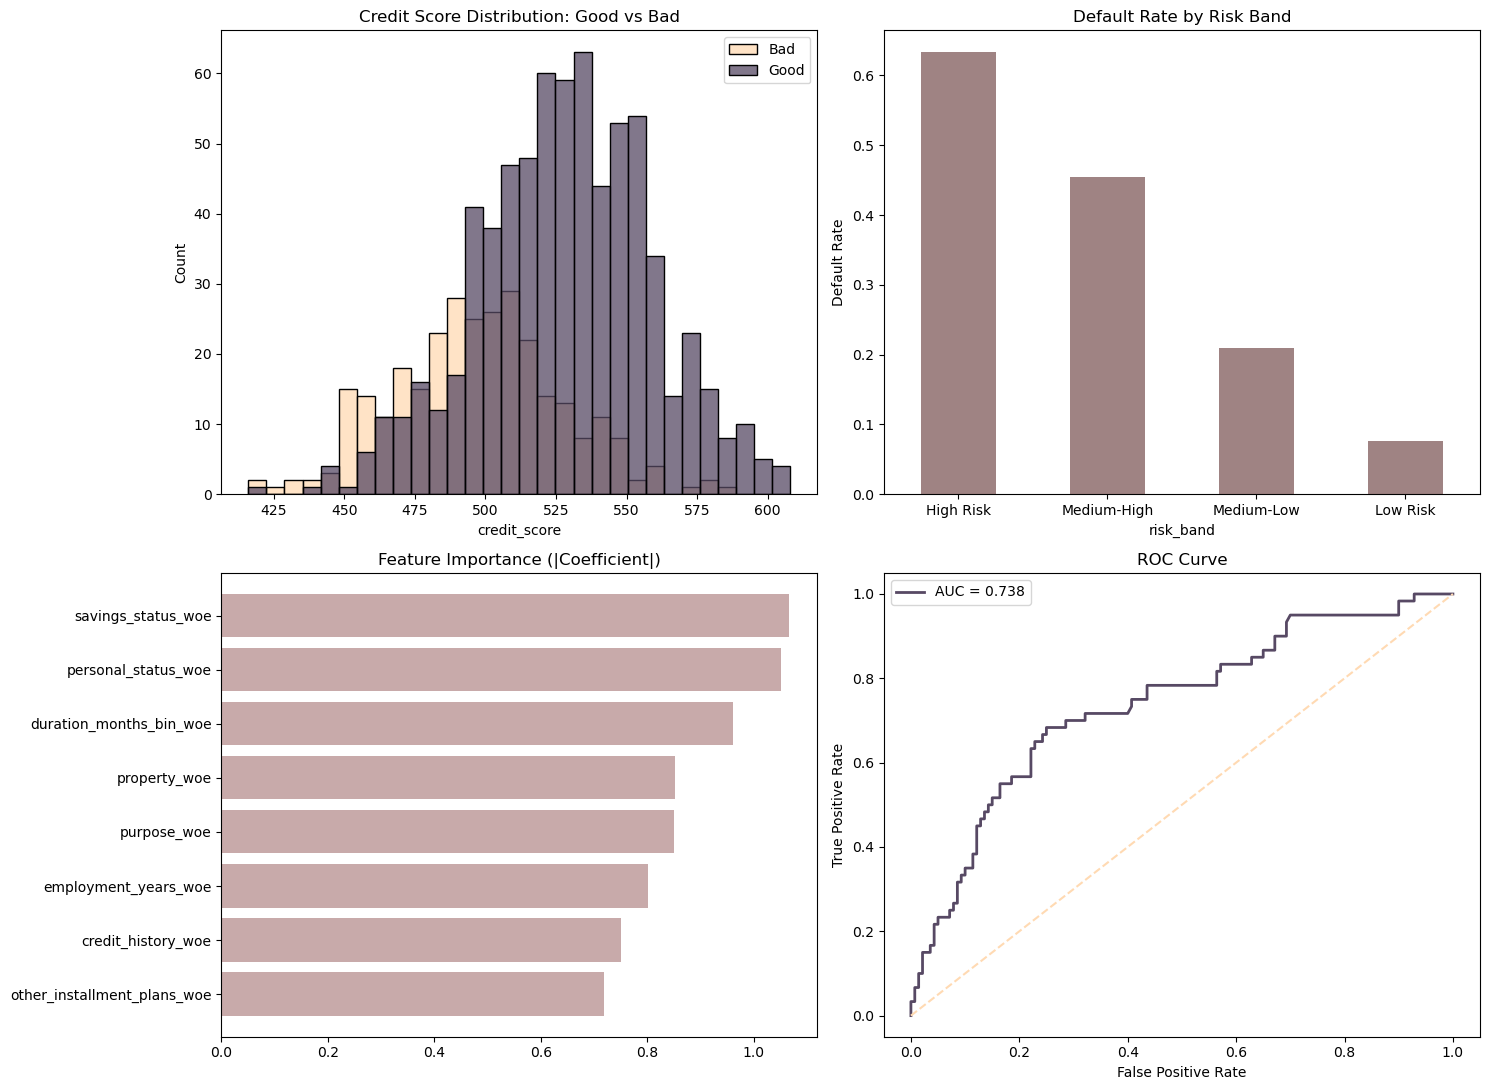

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Score distribution by risk
sns.histplot(data=df, x='credit_score', hue='target', bins=30,
             palette={0: '#574964', 1: '#FFDAB3'}, ax=axes[0,0], alpha=0.75)
axes[0,0].set_title('Credit Score Distribution: Good vs Bad')
axes[0,0].legend(labels=['Bad', 'Good'])

# 2. Default rate by risk band
band_summary['default_rate'].plot(kind='bar', ax=axes[0,1], color='#9F8383')
axes[0,1].set_title('Default Rate by Risk Band')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Feature importance (coefficient magnitude)
coef_df_sorted = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=True).index)
axes[1,0].barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'].abs(), color='#C8AAAA')
axes[1,0].set_title('Feature Importance (|Coefficient|)')

# 4. ROC curve
axes[1,1].plot(fpr, tpr, color='#574964', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1,1].plot([0,1], [0,1], color='#FFDAB3', linestyle='--')
axes[1,1].set_title('ROC Curve')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [ ]:
x